In [52]:
import FinancialMachineLearning as fml


# Introduction
This page is the application of "Advances in Financial Machine Learning" by Marcos López de Prado on Bitcoin market.






# Data

To adapt this approach for use with Bitcoin data, I have downloaded Bitcoin tick data from Binance. While Lopez de Prado's book primarily focuses on tick data, which can often be costly to acquire, Binance provides tick data at no cost, allowing me to proceed without incurring additional expenses.

Binance's low timeframe data includes the number of aggregated ticks, which can be effectively utilized to create tick bars from time bars. This aggregated tick information allows for a more accurate and efficient construction of tick bars, making it well-suited for modeling and analysis in the context of the Bitcoin market.













In [6]:
def time_to_timestamp(s):
    return round(datetime.strptime(s + ' 00:00:00', '%Y-%m-%d %H:%M:%S').timestamp()*1000)


limit = 499


def interval_to_milliseconds(interval):
    if interval == '1m':
        return 1 * 60 * 1000
    elif interval == '3m':
        return 3 * 60 * 1000
    elif interval == '5m':
        return 5 * 60 * 1000
    elif interval == '15m':
        return 15 * 60 * 1000
    elif interval == '30m':
        return 30 * 60 * 1000
    elif interval == '1h':
        return 60 * 60 * 1000
    elif interval == '2h':
        return 2 * 60 * 60 * 1000
    elif interval == '4h':
        return 4 * 60 * 60 * 1000
    elif interval == '6h':
        return 6 * 60 * 60 * 1000
    elif interval == '8h':
        return 8 * 60 * 60 * 1000
    elif interval == '12h':
        return 12 * 60 * 60 * 1000
    elif interval == '1d':
        return 24 * 60 * 60 * 1000
    elif interval == '3d':
        return 3 * 24 * 60 * 60 * 1000
    elif interval == '1w':
        return 7 * 24 * 60 * 60 * 1000


def get_historical_data(ticker, interval, start, end):
    interval_in_milliseconds = interval_to_milliseconds(interval)
    revising_interval_in_milliseconds = interval_to_milliseconds(interval)
    start_time = time_to_timestamp(
        start) - revising_interval_in_milliseconds * 200
    end_time = 0
    ticker_df_4_hour = pd.DataFrame(
        columns=["Time", "open", "high", "low", "close",
                 "volume", 'a', 'b', 'numTrades','takerbuy_base','takerbuy_quote','ignore'])

    while end_time < time_to_timestamp(end) + revising_interval_in_milliseconds:
        try:
            end_time = min(start_time + interval_in_milliseconds * limit,
                           time_to_timestamp(end) + revising_interval_in_milliseconds)

            r = requests.get('https://api.binance.com/api/v3/klines?symbol=' + ticker + '&interval='
                             + interval + '&startTime=' + str(start_time) + '&endTime=' + str(end_time))
            data = r.json()
            array_data = np.array(data)
            
            print(data)
            ticker_df_4_hour = pd.concat([ticker_df_4_hour, pd.DataFrame(array_data,
                                                                         columns=["Time", "open",
                                                                                  "high", "low",
                                                                                  "close",
                                                                                  "volume", 'a', 'b', 'numTrades','takerbuy_base','takerbuy_quote','ignore'])])
            start_time = end_time + interval_in_milliseconds
        except:
            break
    ticker_df_4_hour['Time'] = pd.to_datetime(
        ticker_df_4_hour['Time'], unit='ms')
    ticker_df_4_hour = ticker_df_4_hour.set_index('Time')
    ticker_df_4_hour = ticker_df_4_hour[[
        'open', 'high', 'low', 'close', 'volume', 'numTrades','takerbuy_base']]
    ticker_df_4_hour = ticker_df_4_hour.astype(float)

    return ticker_df_4_hour



In [10]:
from datetime import datetime
import pandas as pd
import requests
# Data download section
interval = '3m'
ticker = 'BTCUSDT'
df = get_historical_data(ticker, interval, "2018-01-01", "2024-08-31")

# Selecting proper bar type

I've carefully considered the appropriate bar type for the Bitcoin market. Given that the Bitcoin market is experiencing rapid growth, the number of ticks is increasing exponentially, making the selection of an appropriate tick size crucial.

To address this challenge, one effective approach is to model Bitcoin data based on the total value traded, considering Bitcoin's limited supply. Specifically, we can allocate 0.1% of the total traded value as the basis for constructing bars.

In this method, each bar would represent an increasing value, allowing us to model the Bitcoin market more accurately and effectively. By doing so, we can ensure that our modeling approach adapts to the dynamic nature of the market while maintaining a consistent representation of the underlying trading activity.



In [32]:
group = 0
cumulative_volume = 0
def dollar_bars(df, supply):
    df = df.reset_index()
    df['dollar_volume'] = df['close'] * df['volume']

    # Define a rolling window size, e.g., last 100 trades
    rolling_window_size = 7

    # Calculate the rolling threshold
#    df['rolling_dollar_volume'] = df['dollar_volume'].rolling(window=rolling_window_size, min_periods=1).sum()
    df['average_price'] = df['close'].rolling(window=10000).mean()
    df['average_price'] = df['average_price'].shift()
    df['rolling_dollar_volume'] = df['average_price'] * supply * 0.001

    # Calculate cumulative dollar volume
    df['cumulative_dollar_volume'] = df['dollar_volume'].cumsum()
    # Group by the threshold
    df['group'] = df.apply(assign_group, axis=1)

    # Group by 'group' and calculate OHLC, sum of volume and trades
    dollar_bar_df = df.groupby('group').agg({'Time': 'first',
                                             'open': 'first',
                                             'high': 'max',
                                             'low': 'min',
                                             'close': 'last',
                                             'volume': 'sum',
                                             'numTrades': 'sum',
                                             })

    # Resetting index to make 'group' a column
    dollar_bar_df.reset_index(inplace=True)
    dollar_bar_df = dollar_bar_df.drop(columns={'group'})
    dollar_bar_df = dollar_bar_df.set_index('Time')
    return dollar_bar_df

def assign_group(row):
    global group, cumulative_volume
    if cumulative_volume + row['dollar_volume'] > row['rolling_dollar_volume']:
        group += 1
        cumulative_volume = row['dollar_volume']
    else:
        cumulative_volume += row['dollar_volume']
    return group

In [63]:
df
df.index = pd.to_datetime(df.index)
coin_supply = 21000000
dollar_df = dollar_bars(df, coin_supply)

dollar_df


,open,high,low,close,volume,numTrades
Time,,,,,,
2017-12-31 04:59:03.552,12924.54,17176.24,9035.00,12563.85,532390.841573,4405485.0
2018-01-21 03:03:46.432,12563.17,12625.00,11200.00,11200.00,23968.600882,206015.0
2018-01-21 16:08:01.280,11200.00,11926.35,10965.00,11721.02,25094.838622,226254.0
2018-01-22 10:26:50.496,11748.86,11786.73,9926.76,9969.68,26636.574610,213101.0
2018-01-22 21:44:02.816,9969.67,10998.00,9900.24,10483.00,27084.740652,236772.0
...,...,...,...,...,...,...
2024-07-21 08:02:11.072,66749.57,68366.66,65777.00,68328.01,18961.657810,1102785.0
2024-07-22 00:38:19.904,68328.00,68474.55,66559.97,67793.99,18922.925020,1411755.0
2024-07-22 22:02:50.240,67793.99,67794.00,65962.00,66657.74,19175.200650,1111212.0


# Fractional differencing method

As we convert the time bar to dollar bar, Next step is to make it stationary data.

Financial data often exhibits a low signal-to-noise ratio as a result of arbitrage activities. A significant concern arises when transforming data to achieve stationarity using standard techniques like integer differencing, as this process can erase the inherent memory of the data, thereby reducing the informational content. Non-stationary data, such as price series, retains memory because each value is dependent on previous price data. In contrast, integer differencing, as applied to returns, disrupts this memory. GARCH (Generalized Autoregressive Conditional Heteroskedasticity) models were developed to remove the memory from the data and extract signals from the residuals. However, despite the complex mathematical framework, GARCH models often yield poor results in volatility forecasting.

It is not difficult to understand that attempting to predict prices using data devoid of memory is likely to lead to incorrect conclusions. Thus, there is a need for a data transformation method that ensures stationarity while preserving as much memory as possible, especially when preparing data for machine learning applications.

We often use integer differencing to transform non-stationary time series data into stationary series for inferential analysis. The objective of this transformation is to work with processes that do not change over time, allowing us to identify recurring patterns. However, a key issue with this transformation is the loss of memory during the process. Simply put, examining only return data does not provide sufficient information about the current price. From a signal processing perspective, the complete loss of memory is undesirable, as memory forms the basis for model predictability. The critical question is: ``What is the minimum level of differencing required to make the price series stationary while preserving as much memory as possible?'' From this perspective, converting prices to returns is just one of many methods.

So, I am introducing the new method of fractional differenciated method which can maintain the memory with the original data, also achieving the stationarity of data.


Let us assume the backshift operator $ B $ applied to a matrix of real-valued characteristics. For all integers $ k \geq 0 $, consider the following for $X_t$:

$$
(1 - B)^2 = (1 - 2B + B^2)
$$

where

$$
B^2 X_t = X_{t-2}
$$

So on,
$$
(1 - B)^2 X_t = X_t - 2X_{t-1} + X_{t-2}
$$

For a positive integer $n$, we can have the expression,
 
$$
(x + y)^n = \sum_{k=0}^{n} \binom{n}{k} x^k y^{n-k} = \sum_{k=0}^{n} \binom{n}{k} x^{n-k} y^k,
$$
we consider the binomial series expansion for a real number $ d $ 
as follows:

$$
(1 + x)^d = \sum_{k=0}^{\infty} \binom{d}{k} x^k
$$

Here, $ d $ can take any real value, and the expansion follows:

$$
(1 - B)^d = \sum_{k=0}^{\infty}  \frac{\prod_{i=0}^{k-1}d-i}{k!} (-B)^k = \sum_{k=0}^{\infty} (-B)^k \prod_{i=0}^{k-1} \frac{d-i}{k-i}
$$

This expands to:

$$
1 - dB + \frac{d(d-1)}{2!}B^2 - \frac{d(d-1)(d-2)}{3!}B^3 + \dots
$$

We can examine how positive, non-integer $d$  maintains memory. This arithmetic series involves an inner product (dot product):

$$
X_t = \sum_{k=0}^{\infty} \omega_k X_{t-k}
$$

where the weights $ \omega $ can be defined as:

$$
\omega = \left\{ 1, -d, \frac{d(d-1)}{2!}, -\frac{d(d-1)(d-2)}{3!}, \dots, (-1)^k \prod_{i=0}^{k-1} \frac{d-i}{k!} \right\}
$$

And the values $ X $:

$$
X = \{X_t, X_{t-1}, X_{t-2}, X_{t-3}, \dots, X_{t-k}, \dots\}
$$

When d is a positive integer, memory decays beyond this point. For example, when $ d = 1 $:

$$
\prod_{i=0}^{k-1} \frac{d-i}{k!} = 0 \quad \forall k > d
$$

and $ \omega = \{1, -1, 0, 0, \dots\} $.



Alternatively, these weights can be recursively computed using:

 $ \omega_0$ = 1 and for k=0, ... , $\infty$:

   $$
   \omega_k = -\omega_{k-1} \frac{d-k+1}{k}
   $$
   

## Apply Fixed Window 

In practice, the infinite series is truncated by discarding weights $ \omega_k $ that fall below a certain threshold $ \tau $
This threshold defines the effective window size $ l^*$, the smallest integer such that:
   $$
   |\omega_{l^*+1}| \leq \tau
   $$

This ensures that the differentiated series $X_{t}^{d}$ captures the long memory effect while avoiding unnecessary computational overhead.



## Differentiation 
Once the effective window size $l^*$ is determined, the fractional differentiation of the time series $X_t$ is computed using only the significant weights:

   $$
   X_t^{(d)} = \sum_{k=0}^{l^*} \omega_k X_{t-k}
   $$
   
This ensures that the differentiated series $ X_t^{(d)}$ captures the long memory effect while avoiding unnecessary computational overhead.

#### Benefits:

- **Memory Efficiency**: By limiting the window, the method reduces the amount of memory needed to store past data points.
  
- **Computational Efficiency**: The fixed window approach reduces computational complexity by focusing only on significant terms.

#### Example:

If $ d = 0.5 $ and the threshold $\tau = 0.01 $, you would calculate the weights $\omega_k $ and find the first $l^*$ where the weights drop below 0.01. Suppose this happens at $l^* = 5 $. You would then use the first 5 weights to differentiate the series:

   $$
   X_t^{(0.5)} = \omega_0 X_t + \omega_1 X_{t-1} + \omega_2 X_{t-2} + \omega_3 X_{t-3} + \omega_4 X_{t-4} + \omega_5 X_{t-5}
   $$

This ensures that the differentiated series $X_t^{(d)} $ is computed using only the most relevant past data points.


0.4 processing
0.6 processing
0.8 processing
1.0 processing
The min. D that makes the fracdiff stationary 0.6


,adfStat,pVal,lags,nObs,95% conf,corr
0.4,-2.125050,0.234562,1.0,21.0,-3.013098,0.817997
0.6,-5.487855,0.000002,1.0,143.0,-2.881973,0.533062
0.8,-19.349867,0.000000,1.0,1221.0,-2.863910,0.112147
1.0,-65.235504,0.000000,1.0,8654.0,-2.861874,0.019452


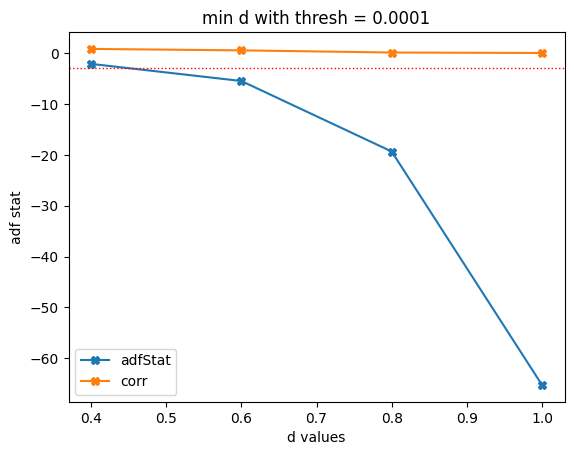

In [64]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

cols = ['adfStat','pVal','lags','nObs','95% conf', 'corr']
out = pd.DataFrame(columns = cols)
for d in np.linspace(0.4, 1, 4):
    try:
        print(f'{d} processing')
        df1 = np.log(dollar_df) # daily return
        df2 = fml.fracDiff(df1, d, thres = 1e-5)
        corr = np.corrcoef(df1.loc[df2.index, 'close'], df2['close'])[0,1]
        df2 = sm.tsa.stattools.adfuller(df2['close'], maxlag = 1, regression = 'c', autolag = None)
        out.loc[d] = list(df2[:4]) + [df2[4]['5%']] + [corr]
    except Exception as e:
        print(f'd: {d.round(1)}, error: {e}')
        continue


min_ffd = out[out.pVal <= 0.05].iloc[0].name
print("The min. D that makes the fracdiff stationary", min_ffd.round(1))
    
f,ax = plt.subplots()
out[['adfStat', 'corr']].plot(ax = ax, marker = 'X')
ax.axhline(out['95% conf'].mean(), lw = 1, color = 'r', ls = 'dotted')
ax.set_title('min d with thresh = 0.0001')
ax.set_xlabel('d values')
ax.set_ylabel('adf stat')
display(out)


It appears that applying fractional differentiation with an order of 0.6 to the dollar bar data successfully makes it stationary, while retaining approximately 53% of the memory from the original price series.

# Feature Engineering

In [123]:
import pandas_ta as ta
dollar_df['frac_diff'] = dfx2

# set the computing period
i = 30

    #수익률계열
dollar_df[f'r_1'] = dollar_df['close'].pct_change(1)

dollar_df[f'r_{i}'] = dollar_df['close'].pct_change(i)
    #변동성계열
dollar_df[f'v_{i}'] = dollar_df[f'r_1'].rolling(10).std()
    # 첨도 (kurtosis)
dollar_df[f'kurtosis_{i}'] = dollar_df[f'r_1'].rolling(window=30).kurt()    
    # 왜도 (skewness)
dollar_df[f'skewness_{i}'] = dollar_df[f'r_1'].rolling(window=30).skew()
    
    #자기상관계수
dollar_df[f'autocorr'] = dollar_df[f'r_1'].rolling(window=30, min_periods=30, center=False).apply(lambda x: x.autocorr(lag=1), raw=False)


dollar_df['autocorr_5'] = dollar_df['frac_diff'].rolling(window=50, min_periods=50, center=False).apply(lambda x: x.autocorr(lag=5), raw=False)
dollar_df['autocorr_10'] = dollar_df['frac_diff'].rolling(window=50, min_periods=50, center=False).apply(lambda x: x.autocorr(lag=10), raw=False)
dollar_df['autocorr_15'] = dollar_df['frac_diff'].rolling(window=50, min_periods=50, center=False).apply(lambda x: x.autocorr(lag=15), raw=False)
dollar_df['autocorr_20'] = dollar_df['frac_diff'].rolling(window=50, min_periods=50, center=False).apply(lambda x: x.autocorr(lag=20), raw=False)
dollar_df['autocorr_30'] = dollar_df['frac_diff'].rolling(window=50, min_periods=50, center=False).apply(lambda x: x.autocorr(lag=30), raw=False)


dollar_df['ATR14'] = ta.atr(dollar_df['high'], dollar_df['low'], dollar_df['close'], length=14)
dollar_df['ATR18'] = ta.atr(dollar_df['high'], dollar_df['low'], dollar_df['close'], length=18)
dollar_df['ATR24'] = ta.atr(dollar_df['high'], dollar_df['low'], dollar_df['close'], length=24)
dollar_df['ATR34'] = ta.atr(dollar_df['high'], dollar_df['low'], dollar_df['close'], length=34)
dollar_df['ATR45'] = ta.atr(dollar_df['high'], dollar_df['low'], dollar_df['close'], length=45)
dollar_df['ATR60'] = ta.atr(dollar_df['high'], dollar_df['low'], dollar_df['close'], length=60)

dollar_df['RSI25'] = ta.rsi(dollar_df['close'], length=25)
dollar_df['RSI35'] = ta.rsi(dollar_df['close'], length=35)
dollar_df['RSI55'] = ta.rsi(dollar_df['close'], length=55)


dollar_df['WILL55'] = ta.willr(dollar_df['high'],dollar_df['low'],dollar_df['close'], length=55)
dollar_df[['DMP','DMN']] = ta.dm(dollar_df['high'], dollar_df['low'])
dollar_df[['MACD','MACDh','MACDs']] = ta.macd(dollar_df['close'])

dollar_df['fracvol15'] = dollar_df['frac_diff'].rolling(15).std()
dollar_df['fracvol31'] = dollar_df['frac_diff'].rolling(31).std()
dollar_df['fracvol50'] = dollar_df['frac_diff'].rolling(50).std()

dollar_df[['TRIX15', 'TRIXs15']] = ta.trix(dollar_df['close'], length=15)
dollar_df[['TRIX30', 'TRIXs30']] = ta.trix(dollar_df['close'], length=30)
dollar_df[['TRIX45', 'TRIXs45']] = ta.trix(dollar_df['close'], length=45)
dollar_df[['TRIX60', 'TRIXs60']] = ta.trix(dollar_df['close'], length=60)

dollar_df['ULTOSC'] = ta.uo(dollar_df['high'], dollar_df['low'], dollar_df['close'])

dollar_df[['BBL', 'BBM', 'BBU', 'BBB', 'BBP']] = ta.bbands(dollar_df['close'])




In [67]:
dollar_df.index = pd.to_datetime(dollar_df.index)

# Downsampling
Up to this point, I've generated continuous, homogeneous, and structured datasets from unstructured financial data collections. While it might be tempting to apply machine learning algorithms to these datasets, this is generally not a good idea for several reasons. First, some machine learning algorithms do not perform efficiently as the sample size increases. Second, machine learning algorithms achieve the highest accuracy when learning from related examples.

For instance, let's assume we want to predict whether the absolute value of a 5% return will be positive or negative. At any arbitrary point in time, the likelihood of making an accurate prediction is very low. However, if we use classification methodologies to predict the sign of the next 5% absolute return after a catalytic event occurs, we are more likely to find informational features that enable more precise predictions. In this article, we will explore how to sample bars to generate a feature matrix with related learning examples.

As mentioned earlier, one reason for sampling features from a structured dataset is to reduce the amount of data used for fitting machine learning algorithms. This process is called downsampling. Often, we sequentially sample at fixed intervals or use a uniform distribution to sample randomly. The advantage of sequential sampling is its simplicity, but its drawback is that the interval size is arbitrary and may fluctuate depending on the seed bar. Uniform distribution sampling addresses this issue by sampling evenly from the entire set of bars. Both methods have been criticized because there is no guarantee that the samples include the most relevant observations in terms of informational content or predictive power.

Portfolio managers place bets after changes in the market's microstructure occur. These events may be linked to increased volatility, excessive deviations from equilibrium levels, or the release of macroeconomic statistics. We can characterize such events as significant and use machine learning to learn whether a function exists that can make precise predictions under these circumstances. The answer may be "no," but in that case, we can redefine the event structure or try again with different features. As an example, let's explore the useful Cusum filter, one of the event-based sampling techniques.

CUSUM (Cumulative Sum) filter is a quality control technique designed to detect how far a measured value has deviated from its target mean value. Let's consider IID observations arising from a locally stationary process. The cumulative sum is defined as follows.


$$
S_t = \max \{0, S_{t-1} + y_t - \mathbb{E}_{t-1} [y_t] \}
$$


The boundary condition here is $ S_0 = 0 $. This procedure will recommend an action at time $ t $ when a certain threshold $ h $ (filter size) is met, specifically when $ S_t \geq h $. Note that $ S_t = 0 $ whenever $ y_t \leq \mathbb{E}_{t-1} [y_t] - S_{t-1} $. The lower bound of 0 implies that downward deviations are ignored so that $ S_t $ does not become negative. This is because the filter is set up to identify sequences that diverge upward from every reset level of 0. In particular, the threshold is activated in the following case.


$$
S_t \geq h \iff \exists \tau \in [1, t] \quad \left| \sum_{i=\tau}^{t} ( y_i - \mathbb{E}_{i-1}[y_t]) \right.   \geq h
$$


This concept of upward accumulation can be extended to include the concept of downward accumulation, which forms a symmetric CUSUM filter.

$$
S_t^+ = \max \{0, S_{t-1}^+ + y_t - \mathbb{E}_{t-1}[y_t]\}, \quad S_0^+ = 0
$$

$$
S_t^- = \max \{0, S_{t-1}^- + y_t - \mathbb{E}_{t-1}[y_t]\}, \quad S_0^- = 0
$$

$$
S_t = \max \{S_t^+, -S_t^-\}
$$


In [68]:
dd_close = dollar_df[['close']]
dfx2 = fml.fracDiff_FFD(dd_close, 0.6, thres= 1e-5)
threshold = dfx2.std().iat[0] 
threshold
tEvents = fml.getTEvents(dfx2.close, h= threshold)

In [69]:
tEvents

,Timestamp
0,2018-09-05 20:00:02.560
1,2018-09-21 03:00:08.320
2,2018-10-15 05:56:24.192
3,2018-10-15 07:01:56.352
4,2018-11-20 15:51:45.408
...,...
1619,2024-07-19 21:53:05.536
1620,2024-07-21 08:02:11.072
1621,2024-07-22 00:38:19.904
1622,2024-07-22 22:02:50.240


In [74]:
dailyVol = fml.getDailyVolatility(dollar_df.close, span = 50)
dailyVol

Time
2018-01-21 03:03:46.432         NaN
2018-01-21 16:08:01.280    0.029324
2018-01-22 10:26:50.496    0.024344
2018-01-22 21:44:02.816    0.020382
2018-01-23 14:52:57.728    0.093888
                             ...   
2024-07-21 08:02:11.072    0.031754
2024-07-22 00:38:19.904    0.031221
2024-07-22 22:02:50.240    0.031096
2024-07-23 14:21:30.496    0.030889
2024-07-24 08:14:06.848    0.030278
Name: dailyVol, Length: 8657, dtype: float64

# Labeling
Instead of labeling observations based solely on the sign of their returns after a fixed period, they are labeled based on whether or not they achieve a return relative to their individual volatilities. This approach allows for observations with higher risk to have a higher expected return, and vice versa. If an observation does not achieve its expected return within a predetermined time frame, it is labeled as 0, indicating that the return is insufficient to warrant a trade. If the observation reaches its expected return in the positive direction (upper barrier), it is labeled as 1, indicating a long position. Conversely, if it reaches the expected return in the negative direction (lower barrier), it is labeled as -1, indicating a short position.

This method, introduced by Dr. Lopez de Prado, is known as the triple-barrier method, where there is a vertical (time) barrier and horizontal barriers for long and short positions.

The fml library was used for the labeling functions, and to expedite computation, the getEvents function leveraged Dr. Lopez de Prado's multiprocessing engine.

In [79]:
closing = dollar_df.close
t1 = fml.addVerticalBarrier(tEvents.Timestamp, closing, numDays = 1)
t1

Timestamp
2018-09-05 20:00:02.560   2018-09-07 09:30:06.720
2018-09-21 03:00:08.320   2018-09-22 08:36:09.856
2018-10-15 05:56:24.192   2018-10-16 15:21:48.288
2018-10-15 07:01:56.352   2018-10-16 15:21:48.288
2018-11-20 15:51:45.408   2018-11-22 03:08:34.176
                                    ...          
2024-07-19 14:05:36.128   2024-07-21 08:02:11.072
2024-07-19 21:53:05.536   2024-07-21 08:02:11.072
2024-07-21 08:02:11.072   2024-07-22 22:02:50.240
2024-07-22 00:38:19.904   2024-07-23 14:21:30.496
2024-07-22 22:02:50.240   2024-07-24 08:14:06.848
Name: Time, Length: 1623, dtype: datetime64[ns]

In [81]:

import platform
cpus = 1
ptsl = [1,1]
target = dailyVol 
minRet = 0.000
events = fml.getEvents(closing, tEvents['Timestamp'], ptsl, target, minRet, cpus, t1 = t1)


labels_one= fml.getBins(events, closing)
labels_one['bin'].value_counts()

2018-09-05 20:00:02.560000
2018-09-21 03:00:08.320000
2018-10-15 05:56:24.192000
2018-10-15 07:01:56.352000
2018-11-20 15:51:45.408000
2018-12-20 00:15:55.392000
2019-05-10 20:56:00.256000
2019-05-17 00:23:21.856000
2019-05-18 23:32:20.096000
2019-05-20 06:42:17.728000
2019-05-26 13:02:14.016000
2019-05-30 16:12:54.144000
2019-06-09 23:04:02.304000
2019-06-21 23:56:07.552000
2019-06-22 16:47:33.888000
2019-06-23 16:03:28.896000
2019-06-23 21:39:53.984000
2019-06-24 19:30:37.184000
2019-06-26 03:17:43.040000
2019-06-26 05:15:40.928000
2019-06-26 14:54:35.008000
2019-06-26 18:41:46.496000
2019-06-26 20:33:11.168000
2019-06-26 22:11:29.408000
2019-06-27 08:10:03.136000
2019-06-27 19:46:55.104000
2019-06-28 01:12:24.832000
2019-06-28 05:36:44.544000
2019-06-28 21:59:46.944000
2019-06-30 10:11:12.512000
2019-07-02 01:21:45.984000
2019-07-02 14:30:22.976000
2019-07-03 18:08:26.624000
2019-07-04 04:35:24.288000
2019-07-04 18:43:00.224000
2019-07-05 23:26:36.032000
2019-07-08 14:32:23.808000
2

bin
 1.0    841
-1.0    782
Name: count, dtype: int64

The process begins by filtering and cleaning the data to isolate the variables directly relevant to price. Next, the feature data (independent variables) is separated from the labels (dependent variable) to prepare for model training. The data is then split into training and testing sets without shuffling, a critical step for preserving the temporal structure, particularly important in time-series data. A relatively large test size of 40% is chosen to account for the cyclical nature of Bitcoin data, ensuring that the model is evaluated on a substantial portion of the dataset.

In [84]:
from sklearn.model_selection import train_test_split
full_df = pd.DataFrame(dollar_df.loc[labels_one['bin'].index], index=labels_one['bin'].index)
full_df.drop(columns=['open','high','close','low','volume','numTrades','BBU','BBL','BBM'],inplace=True)
full_df['labels'] = labels_one['bin'].copy()
full_df =full_df.dropna()
y = full_df['labels'].copy()
full_df.drop(columns=['labels'],inplace=True)
x = full_df.copy()

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(x, y, test_size=0.40,
                                                                        shuffle=False)

X_train_full

,frac_diff,r_1,r_30,v_30,kurtosis_30,skewness_30,autocorr,autocorr_5,autocorr_10,autocorr_15,...,TRIXs15,TRIX30,TRIXs30,TRIX45,TRIXs45,TRIX60,TRIXs60,ULTOSC,BBB,BBP
2018-10-15 05:56:24.192,-458.080390,0.114786,0.117612,0.041199,11.361919,2.788217,0.427398,-0.302928,0.139696,-0.171691,...,-0.002214,-0.036291,-0.038055,-0.051751,-0.054052,-0.059536,-0.061206,62.256931,25.022620,0.978666
2018-10-15 07:01:56.352,51.068462,-0.071398,0.023153,0.049003,8.253919,1.624162,-0.150255,-0.279585,0.133853,-0.128583,...,-0.005301,-0.031914,-0.037060,-0.049983,-0.053297,-0.058599,-0.060714,56.948997,23.489190,0.596644
2018-11-20 15:51:45.408,293.562441,-0.099850,-0.346688,0.044243,2.796469,-0.239884,-0.135007,0.199961,0.300676,0.056395,...,-0.557325,-0.229271,-0.139819,-0.105527,-0.070120,-0.074839,-0.058563,31.984830,16.888122,0.112092
2018-12-20 00:15:55.392,-111.828561,0.070284,0.074521,0.030682,-0.359134,0.132624,0.000154,0.354401,0.013008,-0.034748,...,-0.368837,-0.611677,-0.681281,-0.601990,-0.612684,-0.481994,-0.474788,69.535267,9.525787,0.854884
2019-05-10 20:56:00.256,-339.329008,0.067555,0.275417,0.025557,0.937081,0.332423,-0.160131,0.216688,0.125497,0.237926,...,0.399438,0.361477,0.336004,0.356263,0.349054,0.319443,0.311824,68.783404,14.151494,0.962883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-11 12:39:46.432,441.257048,-0.036027,-0.108091,0.033750,0.281221,0.212193,-0.137640,0.102583,-0.186969,-0.165071,...,-0.064946,-0.009875,-0.002056,-0.034415,-0.036407,-0.084486,-0.090594,40.491701,5.511274,0.253663
2022-03-11 20:44:44.416,-160.756907,0.011659,-0.099906,0.033056,0.198854,0.177035,-0.177870,0.087218,-0.181083,-0.162443,...,-0.066591,-0.013091,-0.003749,-0.034551,-0.035796,-0.083305,-0.089009,42.222177,5.468878,0.483407
2022-03-13 12:28:03.968,336.277173,-0.016760,-0.135043,0.026066,0.591116,0.282566,-0.138504,0.023618,-0.205553,-0.198989,...,-0.076146,-0.021355,-0.008238,-0.035656,-0.035113,-0.081385,-0.086131,40.105495,7.491535,0.170665
2022-03-14 00:59:32.736,-374.523557,0.025212,-0.122516,0.028334,0.362927,0.260342,-0.163353,0.016201,-0.201053,-0.179825,...,-0.084515,-0.025852,-0.011198,-0.036478,-0.035104,-0.080591,-0.084869,43.348822,4.174051,0.651867


# Sample Weights

Observations are assigned weights based on their uniqueness. An observation is considered entirely unique if the time interval used to create its label does not overlap with the intervals of any other observations. The more overlap an observation has, and the longer those overlaps last, the less unique it becomes. Additionally, a linear time-decay is applied to the sample weights, making older observations less significant. This approach to calculating sample weights and determining the uniqueness of observations was introduced by Dr. Lopez de Prado.

The following function utilizes several of Dr. Lopez de Prado's methods to compute sample weights and the average uniqueness of all observations. It also incorporates the previously mentioned multiprocessing engine. The code for these functions can be found in fml library.

In [86]:
t1 = events['t1'].copy()
t1

2018-09-05 20:00:02.560   2018-09-07 09:30:06.720
2018-09-21 03:00:08.320   2018-09-22 08:36:09.856
2018-10-15 05:56:24.192   2018-10-15 07:01:56.352
2018-10-15 07:01:56.352   2018-10-16 15:21:48.288
2018-11-20 15:51:45.408   2018-11-21 14:02:08.256
                                    ...          
2024-07-19 21:53:05.536   2024-07-21 08:02:11.072
2024-07-21 08:02:11.072   2024-07-22 22:02:50.240
2024-07-22 00:38:19.904   2024-07-23 14:21:30.496
2024-07-22 22:02:50.240   2024-07-24 08:14:06.848
2024-07-24 08:14:06.848                       NaT
Name: t1, Length: 1624, dtype: datetime64[ns]

In [88]:
numCoEvents = fml.mpPandasObj(fml.getConcurrentBar, ('molecule', X_train_full.index), cpus, closeIdx = dollar_df.index, t1 = events['t1'])
numCoEvents = numCoEvents.loc[~numCoEvents.index.duplicated(keep = 'last')]
numCoEvents = numCoEvents.reindex(dollar_df.index).fillna(0)
out = pd.DataFrame()
out['tW'] = fml.mpPandasObj(fml.getAvgLabelUniq, ('molecule', X_train_full.index), cpus, t1 = events['t1'], numCoEvents = numCoEvents)
out['w'] = fml.mpPandasObj(fml.mpSampleW, ('molecule', X_train_full.index),
                           cpus, t1 = events['t1'], numCoEvents = numCoEvents, close = dollar_df.close)
out['w'] *= out.shape[0] / out['w'].sum()


def getExTimeDecay(tW, clfLastW = 1.,exponent = 1):
    clfW = tW.sort_index().cumsum()
    if clfLastW >= 0: slope = ((1.-clfLastW)/clfW.iloc[-1]) ** exponent
    else: slope = (1./((clfLastW + 1) * clfW.iloc[-1])) ** exponent
    const = 1.-slope * clfW.iloc[-1]
    clfW = const + slope * clfW
    clfW[clfW < 0] = 0
    print(round(const, 4), round(slope, 4))
    return clfW


sample_weights =out['tW']# getExTimeDecay(out['tW'],0.5)
avgu = out['tW'].mean()



mpPandasObj_1/1
mpPandasObj_1/1
mpPandasObj_1/1


In [90]:
avgu

0.4305792403782557

# Feature Extraction

First, I'm taking my training data and creating orthogonal features from it, kind of like what PCA (Principal Component Analysis) does. I start by standardizing the data, which means I'm adjusting it so that each feature has a mean of 0 and a standard deviation of 1. Then, I calculate the principal components, which are new features that capture the most variance in the data. These components are sorted based on their importance, and I keep only those that account for a certain amount of the total variance—95% in this case.

After that, I standardize the data again to make sure all the features are on the same scale. This step is crucial because PCA is sensitive to the scale of the data. I fit the StandardScaler on the training data and use it to transform both the training and testing data.

Finally, I apply PCA to reduce the dimensionality of my dataset. I transform both the training and testing datasets using the same principal components I identified earlier. This helps to simplify the dataset by keeping only the most important information, which should make it easier for my machine learning model to learn from the data and potentially perform better.

In [91]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

def get_eVec(dot,varThres):
    # compute eVec from dot prod matrix, reduce dimension
    eVal,eVec=np.linalg.eigh(dot)
    idx=eVal.argsort()[::-1] # arguments for sorting eVal desc
    eVal,eVec=eVal[idx],eVec[:,idx]
    #2) only positive eVals
    eVal=pd.Series(eVal,index=['PC_'+str(i+1) for i in range(eVal.shape[0])])
    eVec=pd.DataFrame(eVec,index=dot.index,columns=eVal.index)
    eVec=eVec.loc[:,eVal.index]
    #3) reduce dimension, form PCs
    cumVar=eVal.cumsum()/eVal.sum()
    dim=cumVar.values.searchsorted(varThres)
    eVal,eVec=eVal.iloc[:dim+1],eVec.iloc[:,:dim+1]
    return eVal,eVec

def orthoFeats(dfX,varThres=.95):
    # Given a dataframe dfX of features, compute orthofeatures dfP
    dfZ=dfX.sub(dfX.mean(),axis=1).div(dfX.std(),axis=1) # standardize
    dot=pd.DataFrame(np.dot(dfZ.T,dfZ),index=dfX.columns,columns=dfX.columns)
    eVal,eVec=get_eVec(dot,varThres)
    dfP=np.dot(dfZ,eVec)
    return dfP

#여기서 차원 축소가 일어남
#PCA 이용한 특성축소

import scipy
import sklearn

pc = orthoFeats(X_train_full)
num_feat = pc.shape[1]

scaler = StandardScaler()
new_training = scaler.fit_transform(X_train_full)
new_testing = scaler.transform(X_test_full)

pca = PCA(n_components=num_feat)
X_train_pca = pca.fit_transform(new_training)
X_test_pca = pca.transform(new_testing)

# Model Selection
In this research, three different models were employed as the primary classifiers: a bagged randomforest, a bagged SVM, and an MLP.

The RandomForestClassifier is set up with specific parameters to mitigate overfitting. It uses only a single decision tree (n_estimators=1), with bootstrap=False and class_weight='balanced_subsample' to handle class imbalance and reduce overfitting. The min_weight_fraction_leaf is set to 0.05 to ensure that no leaf node carries too little weight, further preventing overfitting.

# Bagged Randomforest

In [187]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

rf = RandomForestClassifier(
    n_estimators=1,
    criterion='entropy',
    max_features='sqrt',  # equivalent to 'auto' in older versions of DecisionTreeClassifier
    bootstrap=False,
    class_weight='balanced_subsample',
    min_weight_fraction_leaf=0.05,
    random_state=20
)



In [188]:
bagged_rf=BaggingClassifier(base_estimator=rf,n_estimators=1000,max_samples=avgu,
                            max_features=1.,random_state=20)

bagged_rf.fit(X_train_pca,y_train_full,sample_weight=sample_weights)

bc = bagged_rf

              precision    recall  f1-score   support

        -1.0       0.75      0.72      0.73       471
         1.0       0.74      0.77      0.76       501

    accuracy                           0.74       972
   macro avg       0.74      0.74      0.74       972
weighted avg       0.74      0.74      0.74       972

Confusion Matrix
[[337 134]
 [115 386]]

Accuracy
0.7438271604938271


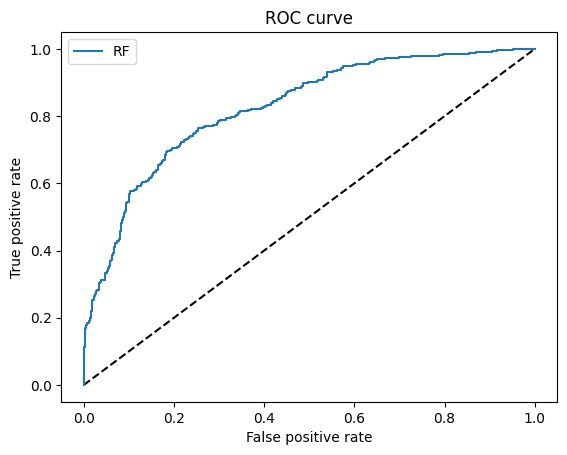

In [189]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

y_pred_rf = bc.predict_proba(X_train_pca)[:, 1]
y_pred = bc.predict(X_train_pca)
fpr_rf, tpr_rf, _ = roc_curve(y_train_full, y_pred_rf)
print(classification_report(y_train_full, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_train_full, y_pred))
print('')
print("Accuracy")
print(accuracy_score(y_train_full, y_pred))

plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_rf, tpr_rf, label='RF')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

              precision    recall  f1-score   support

        -1.0       0.44      0.28      0.34       310
         1.0       0.50      0.67      0.57       339

    accuracy                           0.48       649
   macro avg       0.47      0.48      0.46       649
weighted avg       0.47      0.48      0.46       649

Confusion Matrix
[[ 88 222]
 [113 226]]

Accuracy
0.48382126348228044


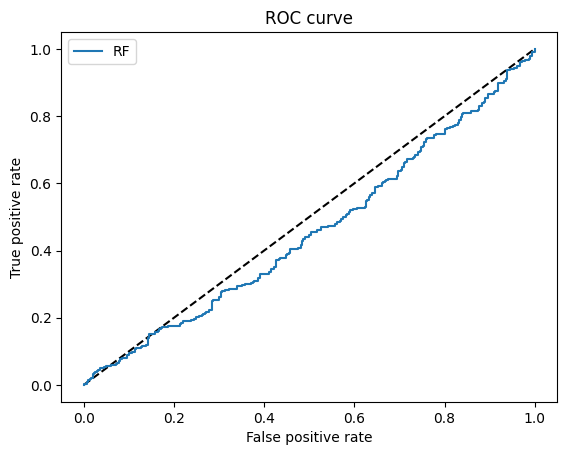

In [190]:
y_pred_rf = bc.predict_proba(X_test_pca)[:, 1]
y_pred = bc.predict(X_test_pca)
fpr_rf, tpr_rf, _ = roc_curve(y_test_full, y_pred_rf)
print(classification_report(y_test_full, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test_full, y_pred))
print('')
print("Accuracy")
print(accuracy_score(y_test_full, y_pred))

plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_rf, tpr_rf, label='RF')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

        pred_prob         close  cali_prediction           z    bet_size  \
count  648.000000    648.000000       648.000000  648.000000  648.000000   
mean     0.531159  40652.520772         0.509284    0.063884    0.063884   
std      0.063726  17232.074925         0.169026    0.131245    0.131245   
min      0.339150  16028.870000         0.000000   -0.339760   -0.339760   
25%      0.488863  26537.627500         0.397097   -0.022279   -0.022279   
50%      0.533406  37223.760000         0.515242    0.066961    0.066961   
75%      0.574874  58812.927500         0.625232    0.151456    0.151456   
max      0.716168  72891.990000         1.000000    0.479461    0.479461   

           profit  
count  648.000000  
mean     0.000070  
std      0.005490  
min     -0.023445  
25%     -0.001914  
50%     -0.000102  
75%      0.001453  
max      0.042980  
                         pred_prob     close  cali_prediction         z  \
2022-03-15 11:41:24.352   0.412060  39523.65         0.19338

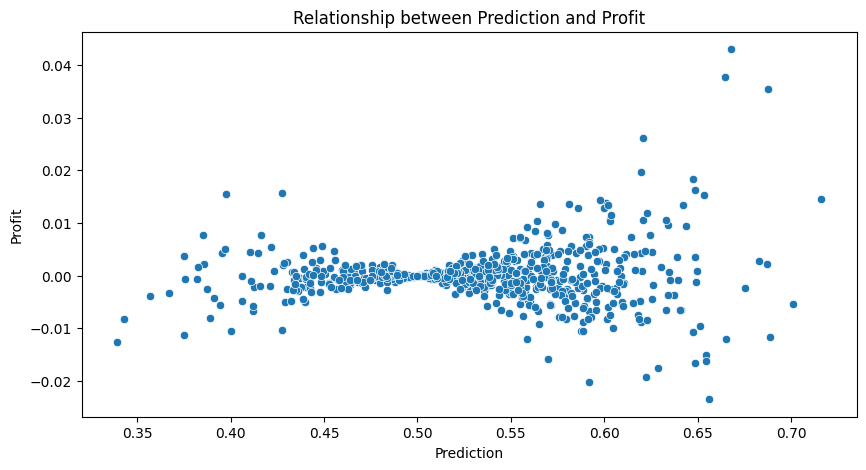

Correlation between cali_prediction and profit for range (0.0, 0.3): nan
Mean profit for range (0.0, 0.3): nan


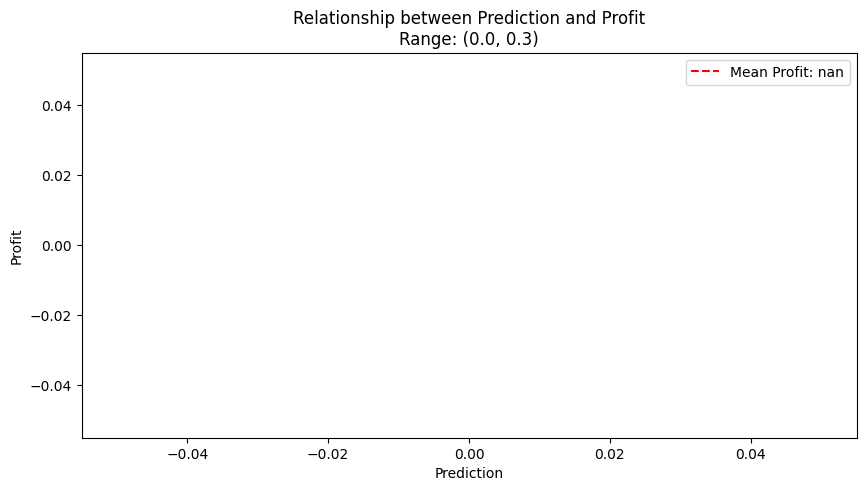

Correlation between cali_prediction and profit for range (0.3, 0.5): 0.17965237560799202
Mean profit for range (0.3, 0.5): -0.0002258114298883756


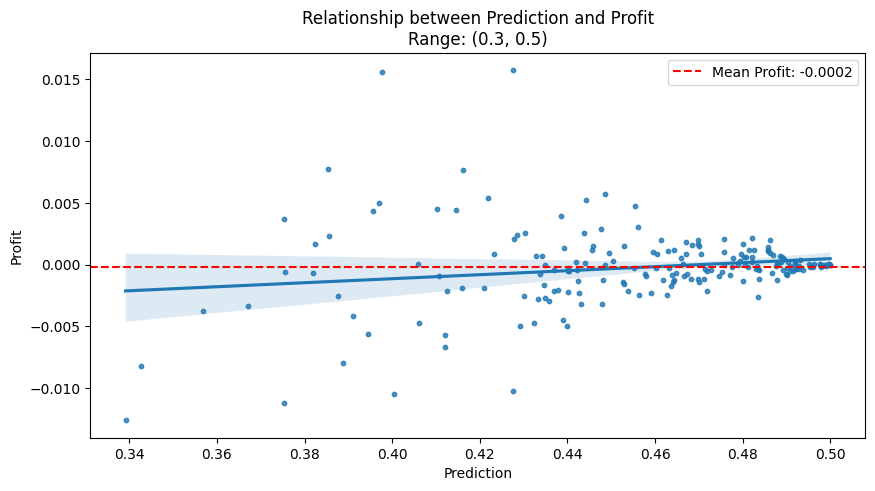

Correlation between cali_prediction and profit for range (0.5, 0.7): 0.07548403994135743
Mean profit for range (0.5, 0.7): 0.0001825312569153362


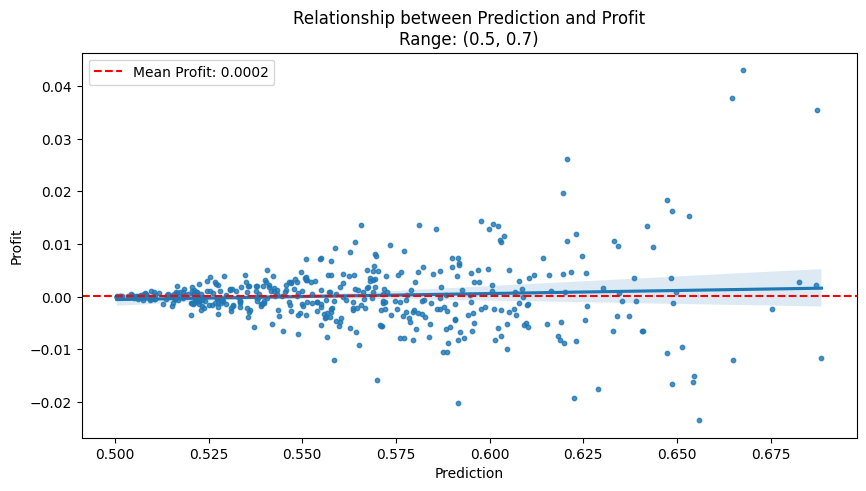

Correlation between cali_prediction and profit for range (0.7, 1.0): 1.0
Mean profit for range (0.7, 1.0): 0.004610758864813256


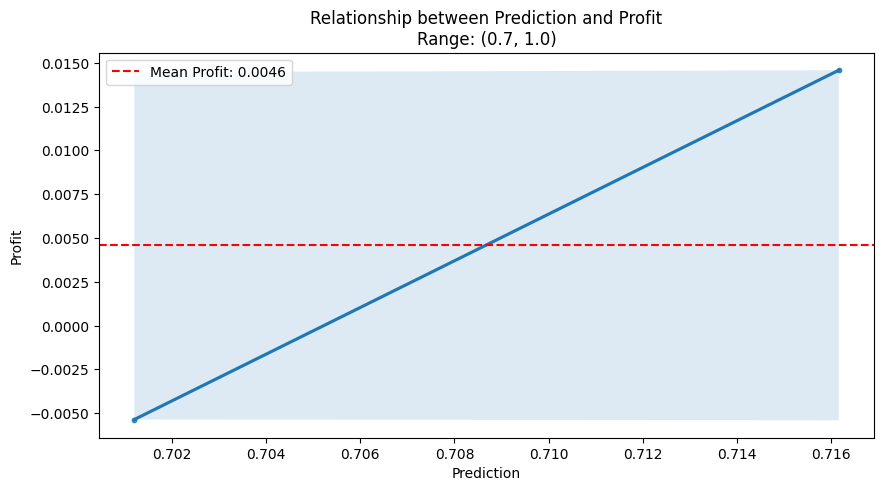

In [191]:
import seaborn as sns
#test data
import pandas as pd
import numpy as np

y_pred_rf = bc.predict_proba(X_test_pca)[:, 1]
y_pred = bc.predict(X_test_pca)

yprf = pd.Series(y_pred_rf, index=X_test_full.index)
yt = pd.DataFrame(yprf, columns=['pred_prob'])
yt['close'] = dollar_df.close

yt['cali_prediction'] = (yprf - yprf.min()) / (yprf.max() - yprf.min())
yt['z'] = (yt['pred_prob'] - 0.5) / np.sqrt(yt['pred_prob'] * (1 - yt['pred_prob']))
yt['bet_size'] = yt['z']
yt['profit'] = yt['bet_size'] * yt['close'].pct_change().shift(-1)

yt = yt.dropna()

print(yt.describe())
print(yt.head())

correlation = yt['pred_prob'].corr(yt['profit'])
print(f"Correlation between cali_prediction and profit: {correlation}")

plt.figure(figsize=(10, 5))
sns.scatterplot(x='pred_prob', y='profit', data=yt)
plt.title('Relationship between Prediction and Profit')
plt.xlabel('Prediction')
plt.ylabel('Profit')
plt.show()


ranges = [(0.0, 0.3), (0.3, 0.5), (0.5, 0.7), (0.7, 1.0)]


for lower, upper in ranges:
    subset = yt[(yt['pred_prob'] > lower) & (yt['pred_prob'] <= upper)]
    correlation = subset['pred_prob'].corr(subset['profit'])
    mean_profit = subset['profit'].mean()
    print(f"Correlation between cali_prediction and profit for range ({lower}, {upper}): {correlation}")
    print(f"Mean profit for range ({lower}, {upper}): {mean_profit}")

    # Plot the relationship for this subset with a linear regression line
    plt.figure(figsize=(10, 5))
    sns.regplot(x='pred_prob', y='profit', data=subset, scatter_kws={'s': 10})
    plt.title(f'Relationship between Prediction and Profit\nRange: ({lower}, {upper})')
    plt.xlabel('Prediction')
    plt.ylabel('Profit')
    plt.axhline(y=mean_profit, color='r', linestyle='--', label=f'Mean Profit: {mean_profit:.4f}')
    plt.legend()
    plt.show()

Final capital after trading: $10465.83
                       date  bet_size     close    profit       capital  \
643 2024-07-18 17:16:02.944 -0.114686  65122.01 -0.003175  10469.385402   
644 2024-07-19 14:05:36.128  0.076744  66925.03 -0.000201  10469.223752   
645 2024-07-19 21:53:05.536  0.034973  66749.58  0.000827  10469.526560   
646 2024-07-21 08:02:11.072 -0.022427  68328.01  0.000175  10469.485406   
647 2024-07-22 00:38:19.904 -0.144362  67793.99  0.002420  10465.828483   

      returns  cumulative_returns  
643  0.000364            1.045692  
644 -0.000015            1.045676  
645  0.000029            1.045706  
646 -0.000004            1.045702  
647 -0.000349            1.045336  


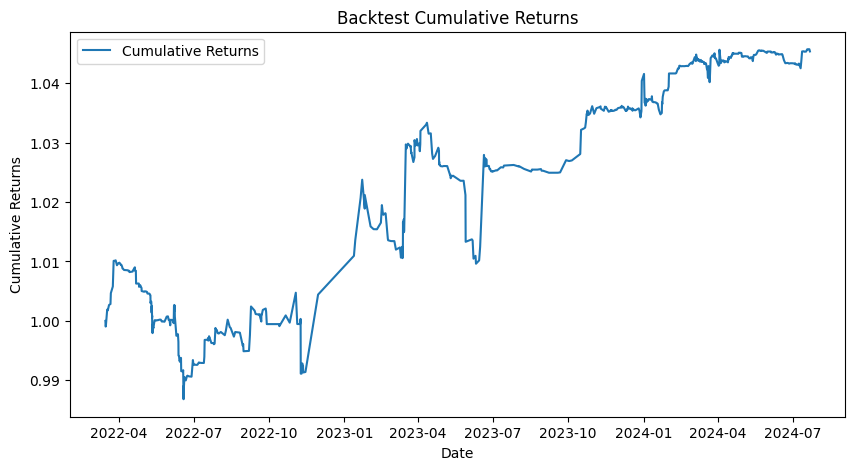

In [192]:

#mannual backtesting
import pandas as pd


initial_capital = 10000  # Initial capital for the trading
capital = initial_capital
results = []

# Simulate
for index, row in yt.iterrows():
    bet_size = row['bet_size']  # How much capital to bet based on 'bet_size'
    potential_profit = row['profit']  # Potential profit from the bet
    close = row['close']
    # Calculate the actual change in capital
    change_in_capital = capital * bet_size * potential_profit  # change in capital is proportional to bet_size and the profit outcome
    capital += change_in_capital  # update capital

    # Store the results
    results.append({
        'date': index,
        'bet_size': bet_size,
        'close' : close,
        'profit': potential_profit,
        'capital': capital
    })

results_df = pd.DataFrame(results)

results_df['returns'] = results_df['capital'].pct_change()
results_df.fillna(0, inplace=True)  # Replace NaN values with 0 in the returns column

results_df['cumulative_returns'] = (1 + results_df['returns']).cumprod()

print(f"Final capital after trading: ${capital:.2f}")
print(results_df.tail())  # Display the last few trades

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(results_df['date'], results_df['cumulative_returns'], label='Cumulative Returns')
plt.title('Backtest Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

# Bagged SVM

In [155]:
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier

svc = SVC(probability=True,gamma='auto',random_state=20)

SVC_bagged=BaggingClassifier(base_estimator=svc,n_estimators=1000,max_samples=avgu,
                                   random_state=20,max_features=1.)



SVC_bagged.fit(X_train_pca,y_train_full,sample_weight=sample_weights)

bc = SVC_bagged


In [156]:
bc

BaggingClassifier(base_estimator=SVC(gamma='auto', probability=True,
                                     random_state=20),
                  max_samples=0.4305792403782557, n_estimators=1000,
                  random_state=20)

              precision    recall  f1-score   support

        -1.0       0.80      0.61      0.69       471
         1.0       0.70      0.85      0.77       501

    accuracy                           0.73       972
   macro avg       0.75      0.73      0.73       972
weighted avg       0.75      0.73      0.73       972

Confusion Matrix
[[285 186]
 [ 73 428]]

Accuracy
0.7335390946502057


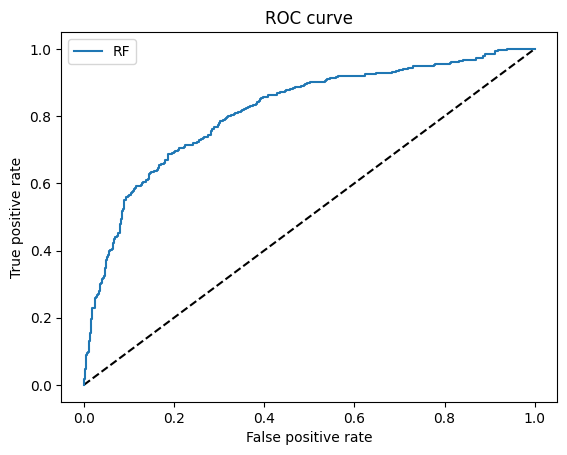

In [157]:
y_pred_rf = bc.predict_proba(X_train_pca)[:, 1]
y_pred = bc.predict(X_train_pca)
fpr_rf, tpr_rf, _ = roc_curve(y_train_full, y_pred_rf)
print(classification_report(y_train_full, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_train_full, y_pred))
print('')
print("Accuracy")
print(accuracy_score(y_train_full, y_pred))

plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_rf, tpr_rf, label='RF')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

              precision    recall  f1-score   support

        -1.0       0.49      0.12      0.19       310
         1.0       0.52      0.89      0.66       339

    accuracy                           0.52       649
   macro avg       0.51      0.50      0.42       649
weighted avg       0.51      0.52      0.43       649

Confusion Matrix
[[ 36 274]
 [ 37 302]]

Accuracy
0.5208012326656395


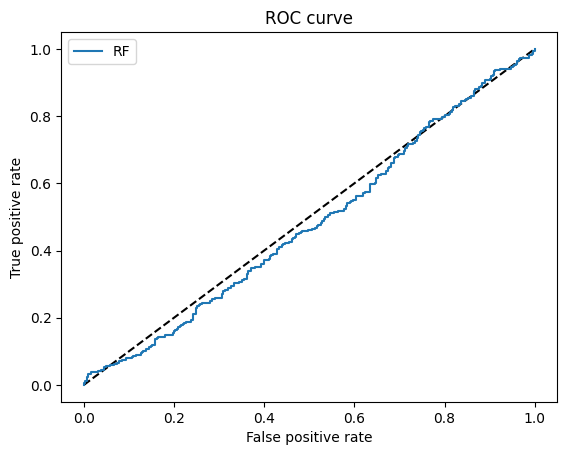

In [158]:
y_pred_rf = bc.predict_proba(X_test_pca)[:, 1]
y_pred = bc.predict(X_test_pca)
fpr_rf, tpr_rf, _ = roc_curve(y_test_full, y_pred_rf)
print(classification_report(y_test_full, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test_full, y_pred))
print('')
print("Accuracy")
print(accuracy_score(y_test_full, y_pred))

plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_rf, tpr_rf, label='RF')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

        pred_prob         close  cali_prediction           z    bet_size  \
count  648.000000    648.000000       648.000000  648.000000  648.000000   
mean     0.528174  40652.520772         0.465550    0.056648    0.056648   
std      0.024363  17232.074925         0.167065    0.049171    0.049171   
min      0.460284  16028.870000         0.000000   -0.079684   -0.079684   
25%      0.512256  26537.627500         0.356399    0.024520    0.024520   
50%      0.527566  37223.760000         0.461382    0.055215    0.055215   
75%      0.543510  58812.927500         0.570716    0.087351    0.087351   
max      0.606110  72891.990000         1.000000    0.217168    0.217168   

           profit  
count  648.000000  
mean     0.000081  
std      0.002452  
min     -0.010151  
25%     -0.001016  
50%      0.000011  
75%      0.001009  
max      0.012441  
                         pred_prob     close  cali_prediction         z  \
2022-03-15 11:41:24.352   0.502635  39523.65         0.29042

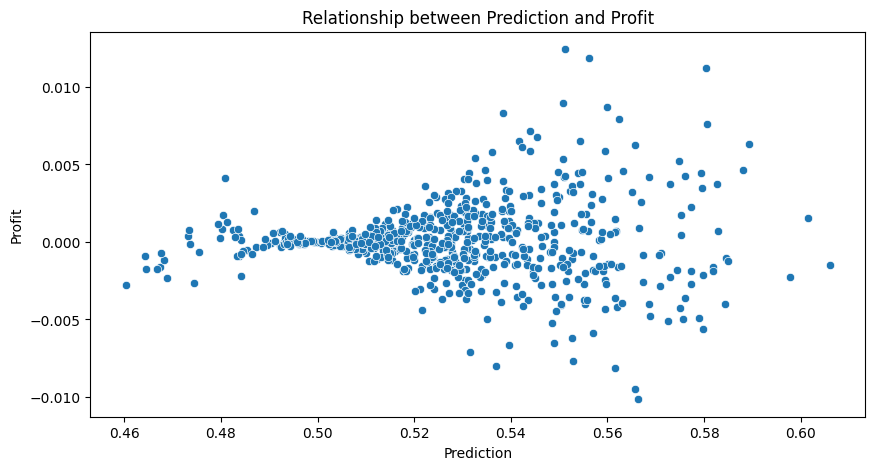

Correlation between cali_prediction and profit for range (0.0, 0.3): nan
Mean profit for range (0.0, 0.3): nan


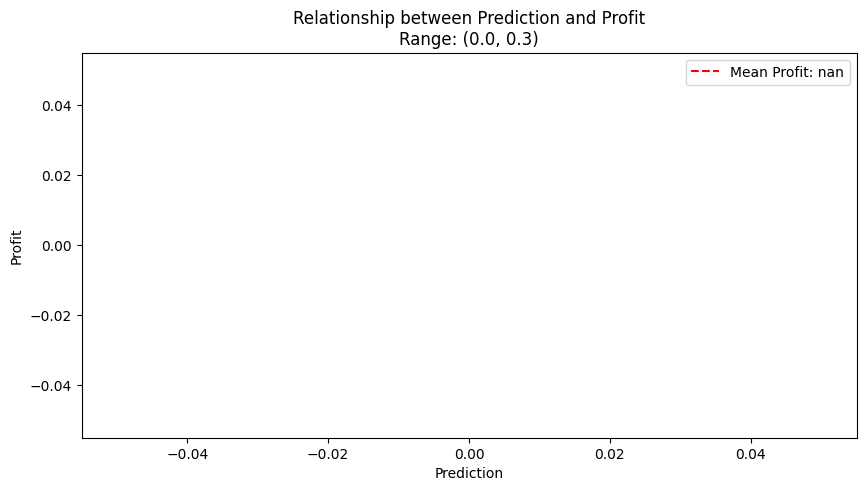

Correlation between cali_prediction and profit for range (0.3, 0.5): 0.3592952558292002
Mean profit for range (0.3, 0.5): -9.299682390323607e-05


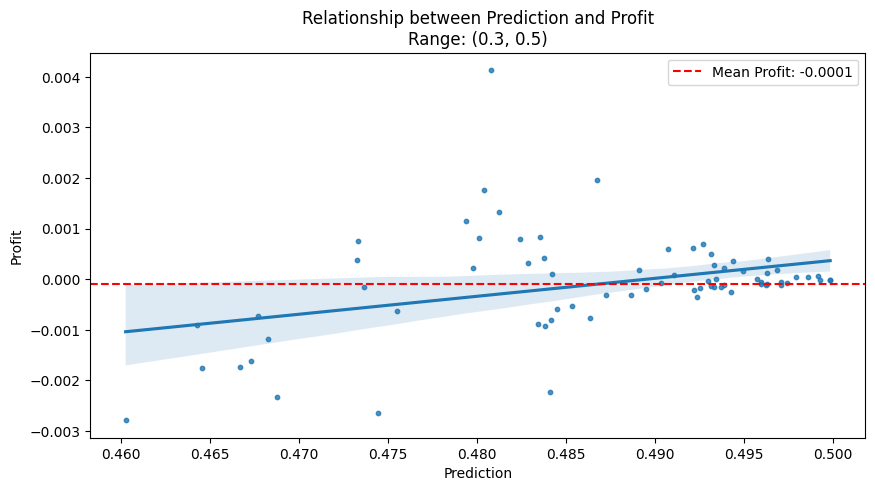

Correlation between cali_prediction and profit for range (0.5, 0.7): 0.012724191150689151
Mean profit for range (0.5, 0.7): 0.00010286742454809633


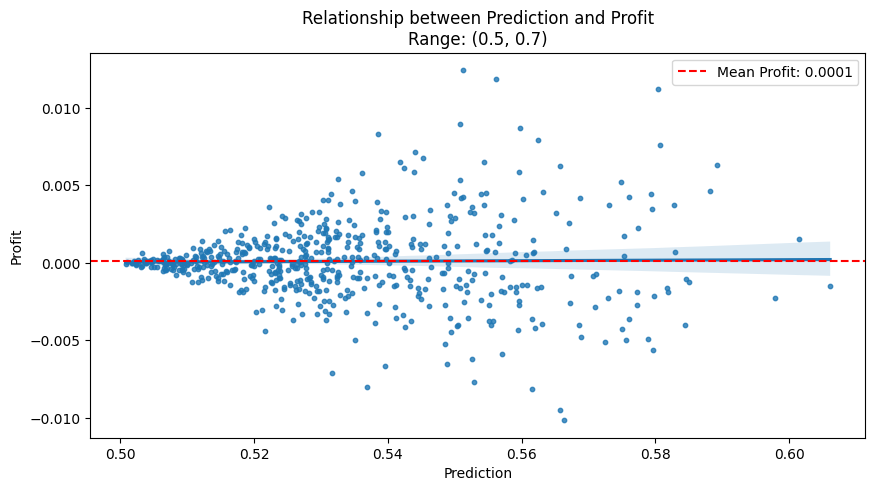

Correlation between cali_prediction and profit for range (0.7, 1.0): nan
Mean profit for range (0.7, 1.0): nan


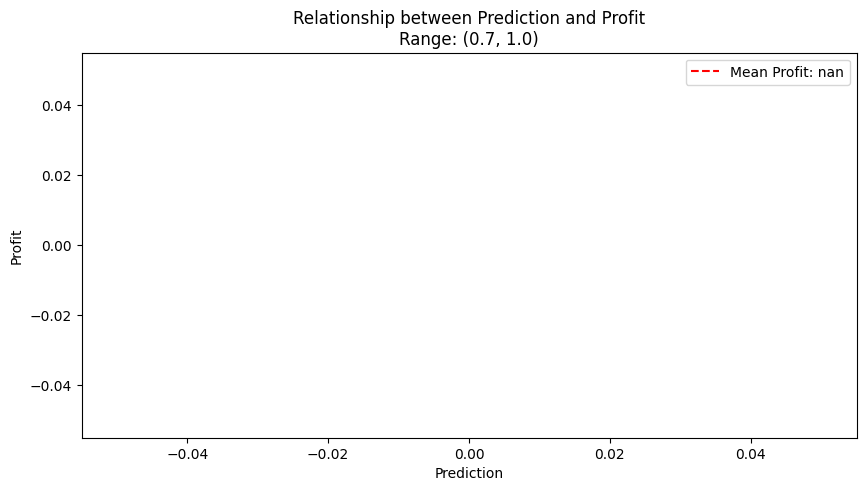

In [159]:
import seaborn as sns
#test data
import pandas as pd
import numpy as np

y_pred_rf = bc.predict_proba(X_test_pca)[:, 1]
y_pred = bc.predict(X_test_pca)

yprf = pd.Series(y_pred_rf, index=X_test_full.index)
yt = pd.DataFrame(yprf, columns=['pred_prob'])
yt['close'] = dollar_df.close

yt['cali_prediction'] = (yprf - yprf.min()) / (yprf.max() - yprf.min())


yt['z'] = (yt['pred_prob'] - 0.5) / np.sqrt(yt['pred_prob'] * (1 - yt['pred_prob']))

yt['bet_size'] = yt['z']

yt['profit'] = yt['bet_size'] * yt['close'].pct_change().shift(-1)

yt = yt.dropna()

print(yt.describe())
print(yt.head())

correlation = yt['pred_prob'].corr(yt['profit'])
print(f"Correlation between cali_prediction and profit: {correlation}")

plt.figure(figsize=(10, 5))
sns.scatterplot(x='pred_prob', y='profit', data=yt)
plt.title('Relationship between Prediction and Profit')
plt.xlabel('Prediction')
plt.ylabel('Profit')
plt.show()


ranges = [(0.0, 0.3), (0.3, 0.5), (0.5, 0.7), (0.7, 1.0)]


for lower, upper in ranges:
    subset = yt[(yt['pred_prob'] > lower) & (yt['pred_prob'] <= upper)]
    correlation = subset['pred_prob'].corr(subset['profit'])
    mean_profit = subset['profit'].mean()
    print(f"Correlation between cali_prediction and profit for range ({lower}, {upper}): {correlation}")
    print(f"Mean profit for range ({lower}, {upper}): {mean_profit}")

    plt.figure(figsize=(10, 5))
    sns.regplot(x='pred_prob', y='profit', data=subset, scatter_kws={'s': 10})
    plt.title(f'Relationship between Prediction and Profit\nRange: ({lower}, {upper})')
    plt.xlabel('Prediction')
    plt.ylabel('Profit')
    plt.axhline(y=mean_profit, color='r', linestyle='--', label=f'Mean Profit: {mean_profit:.4f}')
    plt.legend()
    plt.show()

Final capital after trading: $10497.83
                       date  bet_size     close    profit       capital  \
643 2024-07-18 17:16:02.944 -0.384087  65122.01 -0.010634  10497.630384   
644 2024-07-19 14:05:36.128 -0.085773  66925.03  0.000225  10497.427915   
645 2024-07-19 21:53:05.536 -0.073571  66749.58 -0.001740  10498.771522   
646 2024-07-21 08:02:11.072  0.035581  68328.01 -0.000278  10498.667638   
647 2024-07-22 00:38:19.904 -0.069155  67793.99  0.001159  10497.826130   

      returns  cumulative_returns  
643  0.004084            1.041471  
644 -0.000019            1.041451  
645  0.000128            1.041585  
646 -0.000010            1.041574  
647 -0.000080            1.041491  


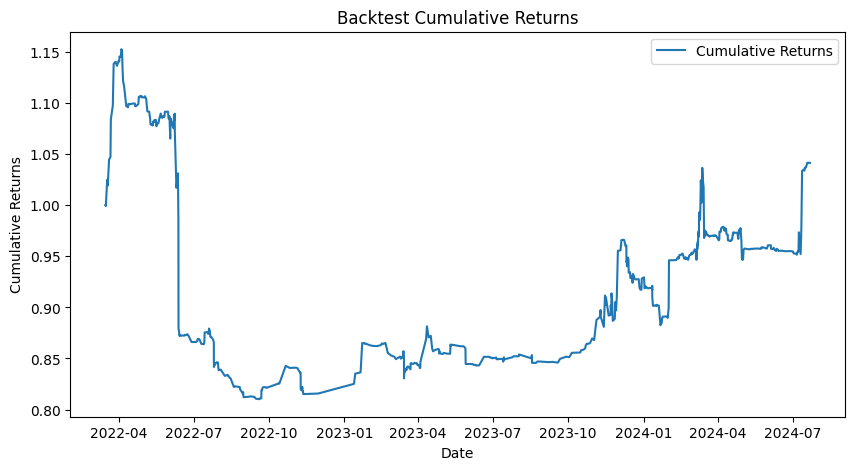

In [118]:

#mannual backtesting
import pandas as pd

initial_capital = 10000  # Initial capital for the trading
capital = initial_capital
results = []

for index, row in yt.iterrows():
    bet_size = row['bet_size']   
    potential_profit = row['profit']  
    close = row['close']
    change_in_capital = capital * bet_size * potential_profit  
    capital += change_in_capital  
    results.append({
        'date': index,
        'bet_size': bet_size,
        'close' : close,
        'profit': potential_profit,
        'capital': capital
    })

results_df = pd.DataFrame(results)

results_df['returns'] = results_df['capital'].pct_change()
results_df.fillna(0, inplace=True)  # Replace NaN values with 0 in the returns column

results_df['cumulative_returns'] = (1 + results_df['returns']).cumprod()

print(f"Final capital after trading: ${capital:.2f}")
print(results_df.tail())  # Display the last few trades

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(results_df['date'], results_df['cumulative_returns'], label='Cumulative Returns')
plt.title('Backtest Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

# MLP (Multi layer perceptron)

In [182]:
from keras.wrappers.scikit_learn import KerasClassifier
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras import optimizers
import numpy as np
import tensorflow as tf

def build_mlp(input_size, lr):
    np.random.seed(0)
    tf.random.set_seed(0)
    
    model = Sequential()
    model.add(Dense(10, input_dim=input_size, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(10, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))  # For binary classification, use 1 unit with 'sigmoid'
    
    optimizer = optimizers.Adam(learning_rate=lr)
    model.compile(loss='binary_crossentropy', optimizer=optimizer)
    return model

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

def clfHyperFitnn(feat, lbl, t1, clf, param_grid, sample_weights, cv=10,
                  rndSearchIter=0, n_jobs=-1, pctEmbargo=0.01):
    if set(lbl.values) == {0, 1}:
        scoring = 'f1'  # f1 for meta-labeling
    else:
        scoring = 'accuracy'  # symmetric towards all cases
    
    inner_cv = fml.PurgedKFold(n_splits=cv, t1=t1, pctEmbargo=pctEmbargo)
    
    if rndSearchIter == 0:
        gs = GridSearchCV(estimator=clf, param_grid=param_grid,
                          scoring=scoring, cv=inner_cv, n_jobs=n_jobs)
    else:
        gs = RandomizedSearchCV(estimator=clf, param_distributions=param_grid,
                                scoring=scoring, cv=inner_cv, n_jobs=n_jobs,
                                n_iter=rndSearchIter)
    
    gs = gs.fit(feat, lbl, sample_weight=sample_weights)
    
    return gs


X_train_pca = pd.DataFrame(X_train_pca, index=X_train_full.index)
mlp = KerasClassifier(build_fn=build_mlp, input_size=X_train_pca.shape[1])

param_grid = {'lr': [0.00001, 0.0001, 0.001, 0.01, 0.1]}

t1cv = t1.loc[X_train_pca.index].copy()


tuned_mlp = clfHyperFitnn(X_train_pca, y_train_full, t1cv, mlp, param_grid, sample_weights, cv=3)
tuned_mlp = tuned_mlp.best_estimator_
print(tuned_mlp)


y_pred = tuned_mlp.predict(X_train_pca)
print(classification_report(y_train_full, y_pred))

31/31 [==============================] - 0s 467us/step
              precision    recall  f1-score   support

        -1.0       0.50      0.58      0.54       471
         1.0       0.54      0.46      0.50       501

    accuracy                           0.52       972
   macro avg       0.52      0.52      0.52       972
weighted avg       0.52      0.52      0.52       972



              precision    recall  f1-score   support

        -1.0       0.50      0.58      0.54       471
         1.0       0.54      0.46      0.50       501

    accuracy                           0.52       972
   macro avg       0.52      0.52      0.52       972
weighted avg       0.52      0.52      0.52       972



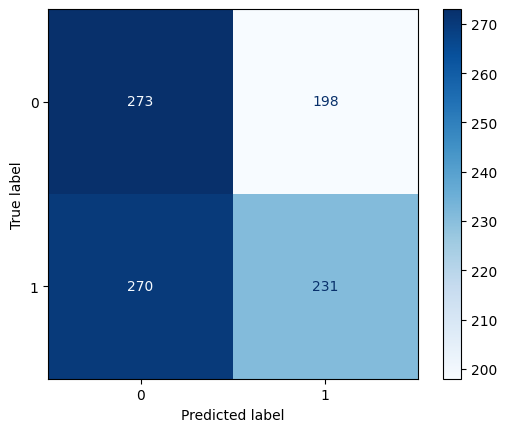

In [183]:


from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print(classification_report(y_train_full, y_pred))

cm = confusion_matrix(y_train_full, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

bc = tuned_mlp

21/21 [==============================] - 0s 600us/step
              precision    recall  f1-score   support

        -1.0       0.45      0.47      0.46       310
         1.0       0.50      0.48      0.49       339

    accuracy                           0.47       649
   macro avg       0.47      0.47      0.47       649
weighted avg       0.48      0.47      0.47       649



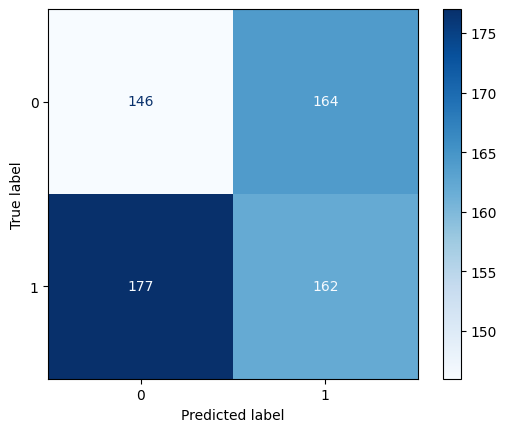

In [184]:

y_pred = tuned_mlp.predict(X_test_pca)
print(classification_report(y_test_full, y_pred))

cm = confusion_matrix(y_test_full, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

bc = tuned_mlp

21/21 [==============================] - 0s 500us/step
        pred_prob         close  cali_prediction           z    bet_size  \
count  648.000000    648.000000       648.000000  648.000000  648.000000   
mean     0.488270  40652.520772         0.519792   -0.035592   -0.035592   
std      0.149806  17232.074925         0.213671    0.355674    0.355674   
min      0.123840  16028.870000         0.000000   -1.141958   -1.141958   
25%      0.403134  26537.627500         0.398362   -0.197473   -0.197473   
50%      0.501952  37223.760000         0.539307    0.003904    0.003904   
75%      0.588751  58812.927500         0.663109    0.180365    0.180365   
max      0.824947  72891.990000         1.000000    0.855097    0.855097   

           profit  
count  648.000000  
mean    -0.000299  
std      0.010194  
min     -0.070964  
25%     -0.003592  
50%     -0.000046  
75%      0.003176  
max      0.051571  
                         pred_prob     close  cali_prediction         z  \
2022-

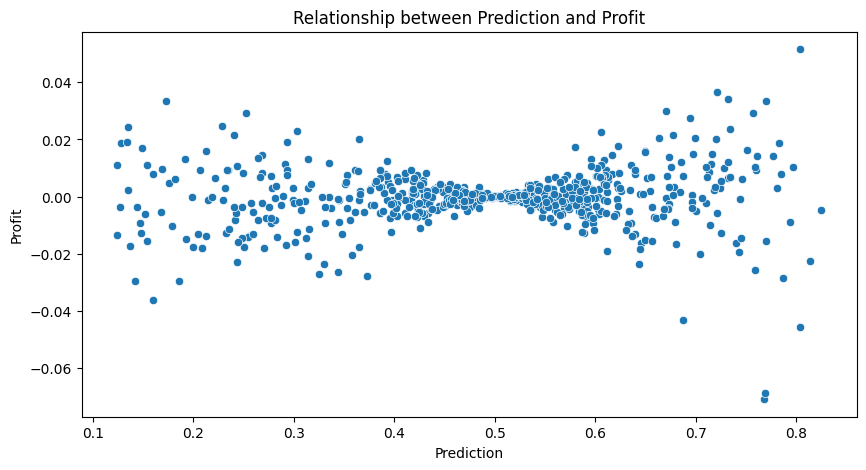

Correlation between cali_prediction and profit for range (0.0, 0.3): 0.012063184289794183
Mean profit for range (0.0, 0.3): -0.001407972891020949


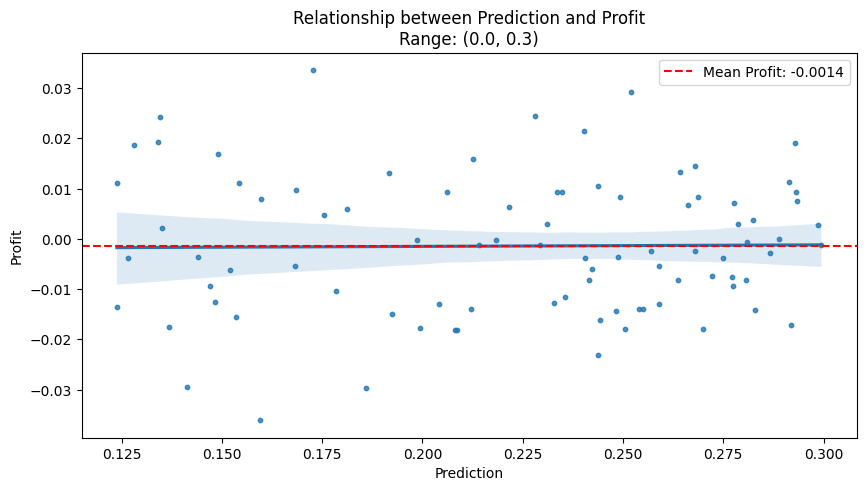

Correlation between cali_prediction and profit for range (0.3, 0.5): 0.19162631299796445
Mean profit for range (0.3, 0.5): -0.0007362799111244708


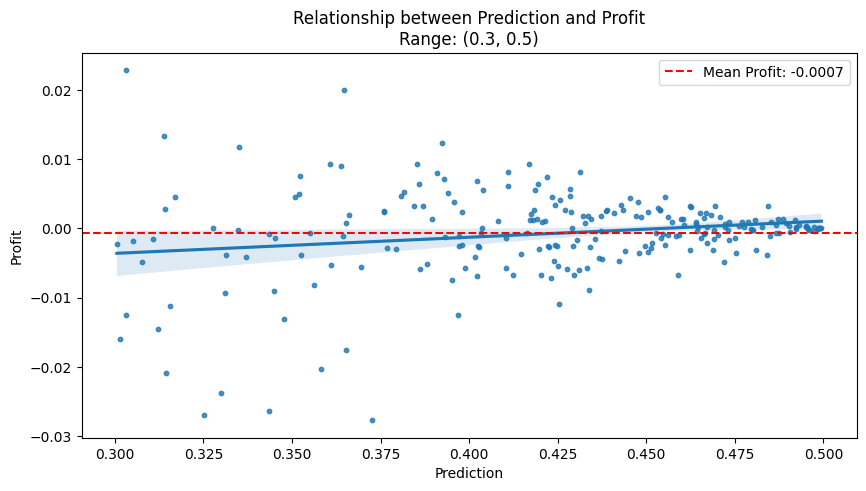

Correlation between cali_prediction and profit for range (0.5, 0.7): 0.0764817476700592
Mean profit for range (0.5, 0.7): 0.00021817127867094385


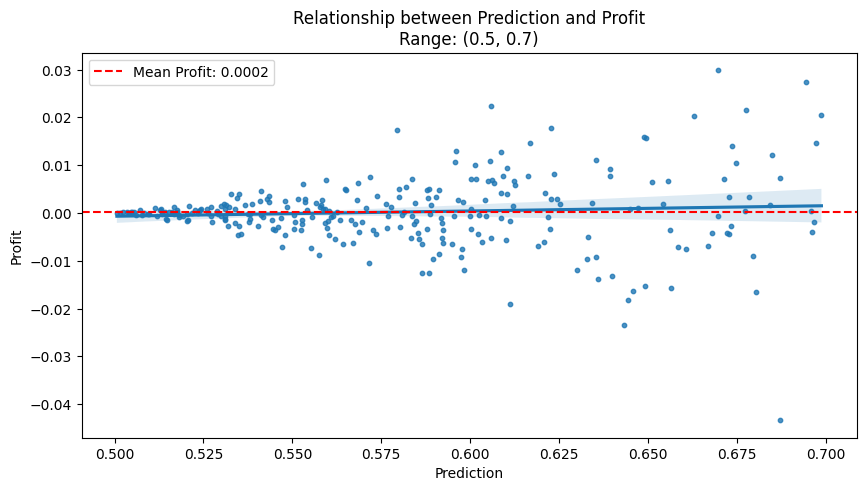

Correlation between cali_prediction and profit for range (0.7, 1.0): -0.16228580776857499
Mean profit for range (0.7, 1.0): 0.0008408212349404138


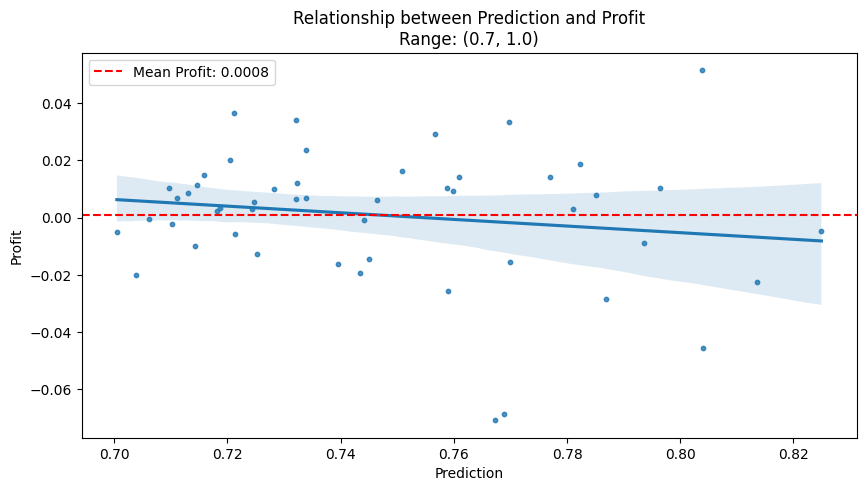

In [185]:
import seaborn as sns
#test data
import pandas as pd
import numpy as np

y_pred_rf = bc.predict_proba(X_test_pca)[:, 1]
y_pred = bc.predict(X_test_pca)

yprf = pd.Series(y_pred_rf, index=X_test_full.index)
yt = pd.DataFrame(yprf, columns=['pred_prob'])
yt['close'] = dollar_df.close

yt['cali_prediction'] = (yprf - yprf.min()) / (yprf.max() - yprf.min())

yt['z'] = (yt['pred_prob'] - 0.5) / np.sqrt(yt['pred_prob'] * (1 - yt['pred_prob']))

yt['bet_size'] = yt['z']

yt['profit'] = yt['bet_size'] * yt['close'].pct_change().shift(-1)

yt = yt.dropna()

print(yt.describe())
print(yt.head())

correlation = yt['pred_prob'].corr(yt['profit'])
print(f"Correlation between cali_prediction and profit: {correlation}")

plt.figure(figsize=(10, 5))
sns.scatterplot(x='pred_prob', y='profit', data=yt)
plt.title('Relationship between Prediction and Profit')
plt.xlabel('Prediction')
plt.ylabel('Profit')
plt.show()


ranges = [(0.0, 0.3), (0.3, 0.5), (0.5, 0.7), (0.7, 1.0)]


for lower, upper in ranges:
    subset = yt[(yt['pred_prob'] > lower) & (yt['pred_prob'] <= upper)]
    correlation = subset['pred_prob'].corr(subset['profit'])
    mean_profit = subset['profit'].mean()
    print(f"Correlation between cali_prediction and profit for range ({lower}, {upper}): {correlation}")
    print(f"Mean profit for range ({lower}, {upper}): {mean_profit}")

    # Plot the relationship for this subset with a linear regression line
    plt.figure(figsize=(10, 5))
    sns.regplot(x='pred_prob', y='profit', data=subset, scatter_kws={'s': 10})
    plt.title(f'Relationship between Prediction and Profit\nRange: ({lower}, {upper})')
    plt.xlabel('Prediction')
    plt.ylabel('Profit')
    plt.axhline(y=mean_profit, color='r', linestyle='--', label=f'Mean Profit: {mean_profit:.4f}')
    plt.legend()
    plt.show()

Final capital after trading: $11798.49
                       date  bet_size     close    profit       capital  \
643 2024-07-18 17:16:02.944 -0.326400  65122.01 -0.009037  11860.599365   
644 2024-07-19 14:05:36.128 -0.279654  66925.03  0.000733  11858.167644   
645 2024-07-19 21:53:05.536 -0.550179  66749.58 -0.013010  11943.047063   
646 2024-07-21 08:02:11.072 -0.483586  68328.01  0.003779  11921.218669   
647 2024-07-22 00:38:19.904 -0.783730  67793.99  0.013136  11798.492628   

      returns  cumulative_returns  
643  0.002950            1.186051  
644 -0.000205            1.185808  
645  0.007158            1.194296  
646 -0.001828            1.192113  
647 -0.010295            1.179840  


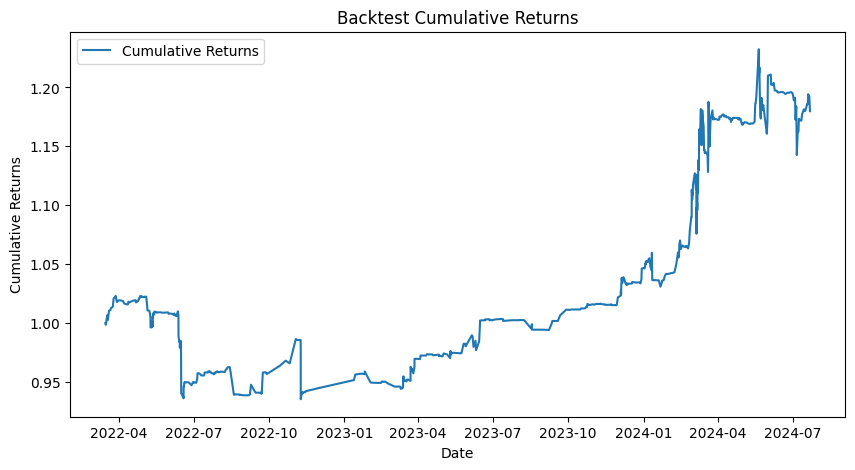

In [186]:

#mannual backtesting
import pandas as pd


initial_capital = 10000  
capital = initial_capital
results = []

for index, row in yt.iterrows():
    bet_size = row['bet_size']   
    potential_profit = row['profit']  
    close = row['close']
    
    change_in_capital = capital * bet_size * potential_profit  
    capital += change_in_capital  

    # Store the results
    results.append({
        'date': index,
        'bet_size': bet_size,
        'close' : close,
        'profit': potential_profit,
        'capital': capital
    })


results_df = pd.DataFrame(results)

# Add a calculation for returns
results_df['returns'] = results_df['capital'].pct_change()
results_df.fillna(0, inplace=True)  # Replace NaN values with 0 in the returns column

# Calculate cumulative returns
results_df['cumulative_returns'] = (1 + results_df['returns']).cumprod()

# Print the final results
print(f"Final capital after trading: ${capital:.2f}")
print(results_df.tail())  # Display the last few trades

# Optional: Plotting the cumulative returns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(results_df['date'], results_df['cumulative_returns'], label='Cumulative Returns')
plt.title('Backtest Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()



# Conclusion

The attempt to predict Bitcoin returns using the current model has proven unsuccessful, as the model exhibits a clear bias towards predicting positive future returns regardless of market conditions. This highlights a significant limitation in the model's ability to accurately capture the complexities of Bitcoin's price dynamics.

To address these shortcomings, two potential avenues for improvement are proposed:

- Enhanced Feature Engineering and Incorporation of On-chain Data: <br> By refining the features used in the model and integrating on-chain data, it may be possible to capture more relevant market signals, thereby improving the model's predictive accuracy.

- Utilizing More Appropriate Simulation Inputs: <br> Developing input data through simulations based on a more suitable and robust base model could help mitigate the current data limitations, providing a richer and more varied dataset for training.

These adjustments represent important future directions for this research, with the potential to significantly enhance the model's performance in predicting Bitcoin returns.